# Prac 08.2

In this homework we will be working with the **Fashion MNIST** dataset. A baseline classifier is provided which suffers from significant overfitting. The objective is to apply regularization techniques to push validation accuracy above **91%** without increasing the model size beyond the baseline.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
)
from tensorflow.keras import Model

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset from Zalando Research consists of 28x28 grayscale images across 10 clothing categories:
0 T-shirt/top, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat, 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

classes = {0:'T-shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat',
           5:'Sandal',  6:'Shirt',   7:'Sneaker',  8:'Bag',   9:'Boot'}
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test),  'samples')
print('Sample dims: ', x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


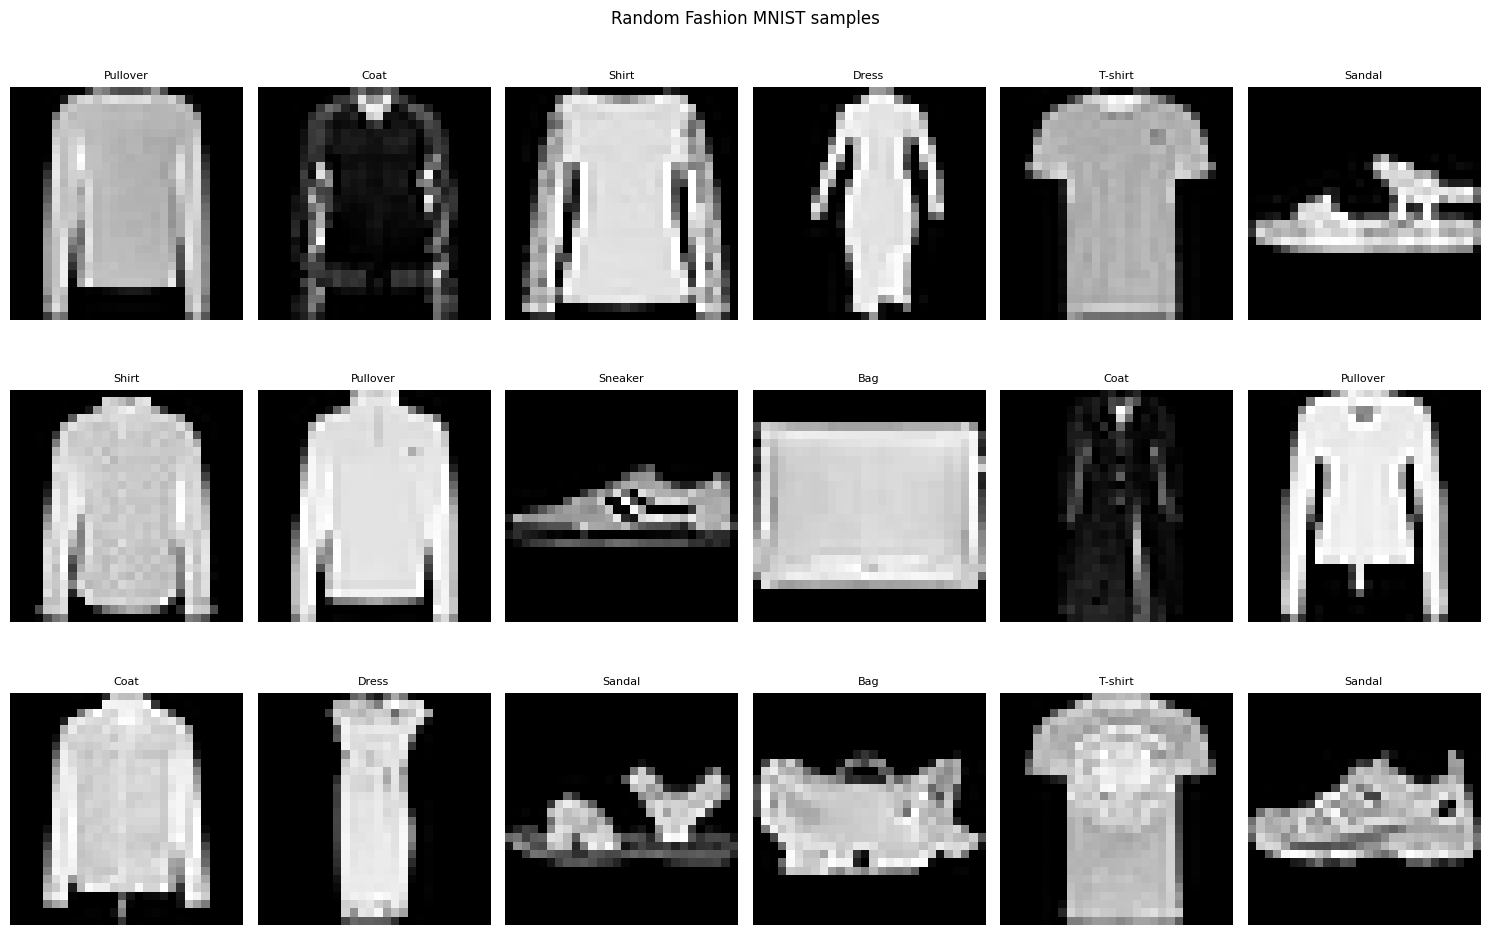

In [3]:
# Visualise random samples
cnt = 1
np.random.seed(0)
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3, 6, cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(classes[int(y_train[idx])], fontsize=8)
        plt.axis('off')
        cnt += 1
plt.suptitle('Random Fashion MNIST samples')
plt.tight_layout()

### Baseline Classifier (overfitting)

In [4]:
# Data normalisation
x_train = x_train / 255.0
x_test  = x_test  / 255.0

In [5]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation='softmax')(net)

model_base = Model(inputs, outputs)
model_base.summary()
print(f'Baseline parameters: {model_base.count_params():,}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

Baseline parameters: 3,213,002


In [6]:
epochs = 50
batch_size = 64

model_base.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_base = model_base.fit(x_train, y_train,
                               batch_size=batch_size, epochs=epochs,
                               validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8611 - loss: 0.3982 - val_accuracy: 0.8818 - val_loss: 0.3316
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9046 - loss: 0.2670 - val_accuracy: 0.8914 - val_loss: 0.3086
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9197 - loss: 0.2240 - val_accuracy: 0.8922 - val_loss: 0.3097
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9308 - loss: 0.1939 - val_accuracy: 0.8922 - val_loss: 0.3278
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9403 - loss: 0.1694 - val_accuracy: 0.8940 - val_loss: 0.3486
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9477 - loss: 0.1500 - val_accuracy: 0.8898 - val_loss: 0.3819
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9543 - loss: 0.1315 - val_accuracy: 0.8921 - val_loss: 0.4121
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9586 - loss: 0.1194 - val_accur

Train Acc      0.9942833185195923
Validation Acc 0.8852999806404114


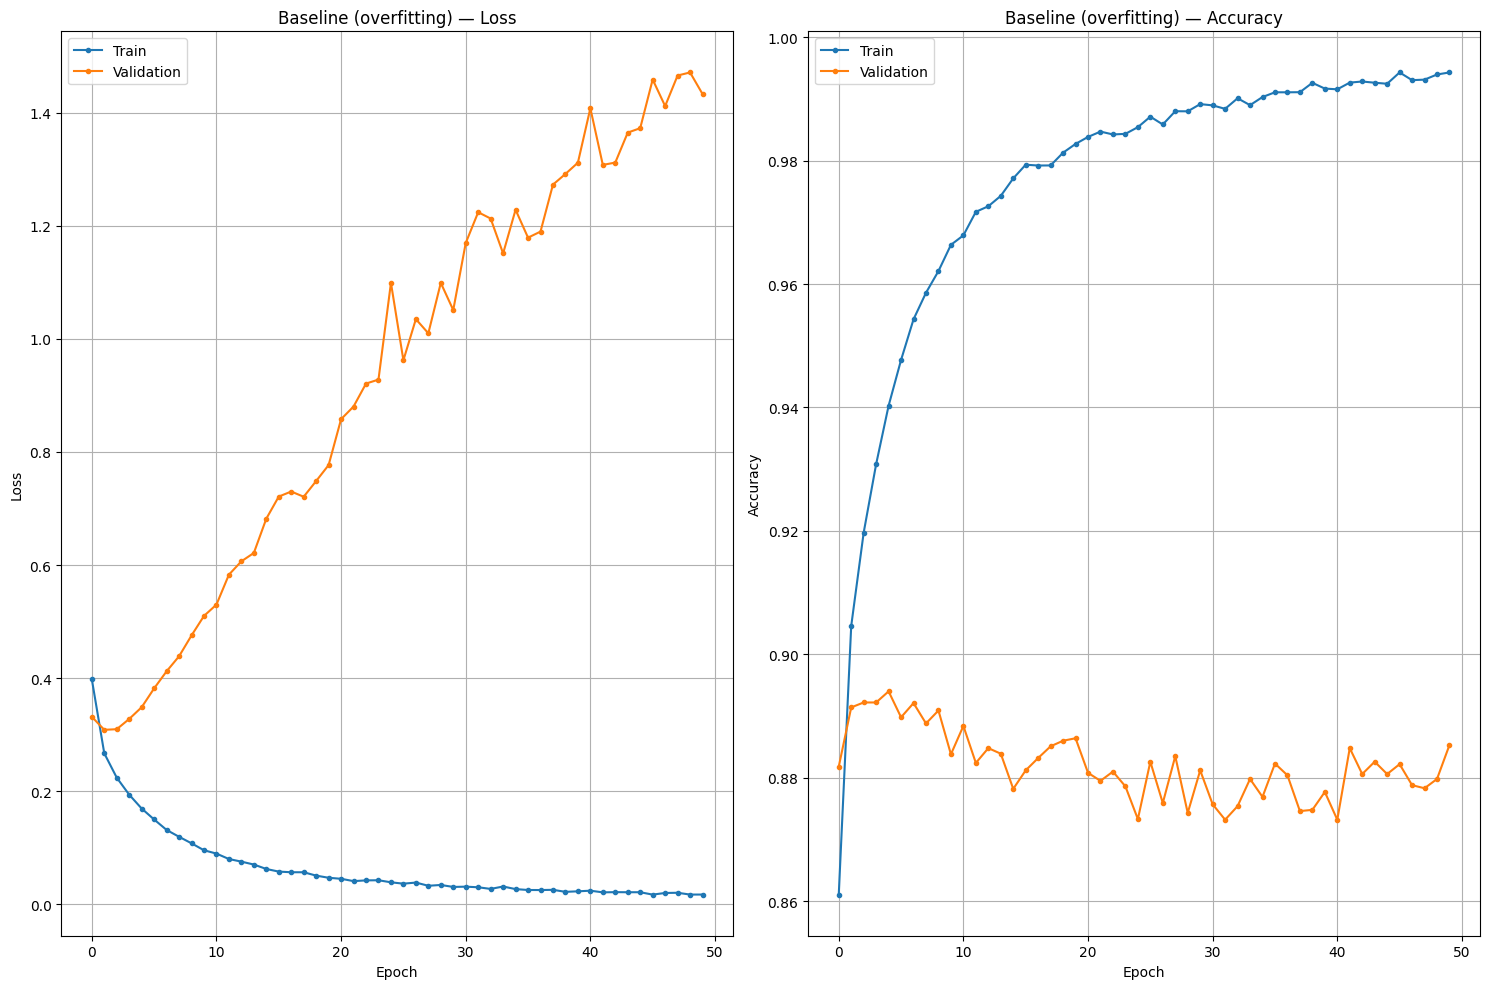

In [7]:
def plot_history(history, title=''):
    h = history.history
    ep = range(len(h['loss']))
    plt.subplot(121)
    plt.plot(ep, h['loss'], '.-', ep, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('Epoch'), plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])
    plt.title(title + ' — Loss')
    plt.subplot(122)
    plt.plot(ep, h['accuracy'], '.-', ep, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('Epoch'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.title(title + ' — Accuracy')
    plt.tight_layout()
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history_base, 'Baseline (overfitting)')

As expected, the baseline overfits heavily: training accuracy approaches 100% while validation accuracy stagnates at ~88%. The large Dense(128) layer applied directly to 25 088 flattened pixels has too many parameters and no spatial pooling, making it easy to memorise the training data.

### Combat the Overfitting!

**Regularization techniques applied:**
1. **MaxPooling** — reduces spatial resolution before Dense layers, cutting parameters by ~16x
2. **Batch Normalization** — stabilises activations, acts as implicit regularizer
3. **Dropout(0.25)** after each conv block, **Dropout(0.5)** before final Dense — randomly disables neurons
4. **Smaller Dense layer** (64 instead of 128) — fewer parameters to overfit

Total parameters: ~220K vs baseline ~3.2M — much smaller, yet more accurate.

In [8]:
inputs2 = Input(shape=(28, 28, 1))

# Block 1
net2 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs2)
net2 = MaxPooling2D((2, 2))(net2)
net2 = BatchNormalization()(net2)
net2 = Dropout(0.25)(net2)

# Block 2
net2 = Conv2D(64, (3, 3), activation='relu', padding='same')(net2)
net2 = MaxPooling2D((2, 2))(net2)
net2 = BatchNormalization()(net2)
net2 = Dropout(0.25)(net2)

# Classifier head
net2 = Flatten()(net2)
net2 = Dense(64, activation='relu')(net2)
net2 = BatchNormalization()(net2)
net2 = Dropout(0.5)(net2)
outputs2 = Dense(10, activation='softmax')(net2)

model2 = Model(inputs2, outputs2)
model2.summary()
print(f'Improved model parameters: {model2.count_params():,}')
print(f'Baseline parameters:       {model_base.count_params():,}')
print(f'Model is smaller: {model2.count_params() < model_base.count_params()}')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,874 (862.79 KB)

 Trainable params: 220,554 (861.54 KB)

 Non-trainable params: 320 (1.25 KB)

Improved model parameters: 220,874
Baseline parameters:       3,213,002
Model is smaller: True


In [9]:
# Train the improved model
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history2 = model2.fit(x_train, y_train,
                      batch_size=batch_size, epochs=epochs,
                      validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8223 - loss: 0.5134 - val_accuracy: 0.8752 - val_loss: 0.3476
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8768 - loss: 0.3486 - val_accuracy: 0.8838 - val_loss: 0.3175
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8903 - loss: 0.3115 - val_accuracy: 0.9002 - val_loss: 0.2674
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8988 - loss: 0.2867 - val_accuracy: 0.8957 - val_loss: 0.2849
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9038 - loss: 0.2710 - val_accuracy: 0.8995 - val_loss: 0.2861
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9065 - loss: 0.2607 - val_accuracy: 0.9093 - val_loss: 0.2556
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9107 - loss: 0.2522 - val_accuracy: 0.9090 - val_loss: 0.2564
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9132 - loss: 0.2426 - val_accuracy: 0.

Train Acc      0.9435499906539917
Validation Acc 0.9302999973297119


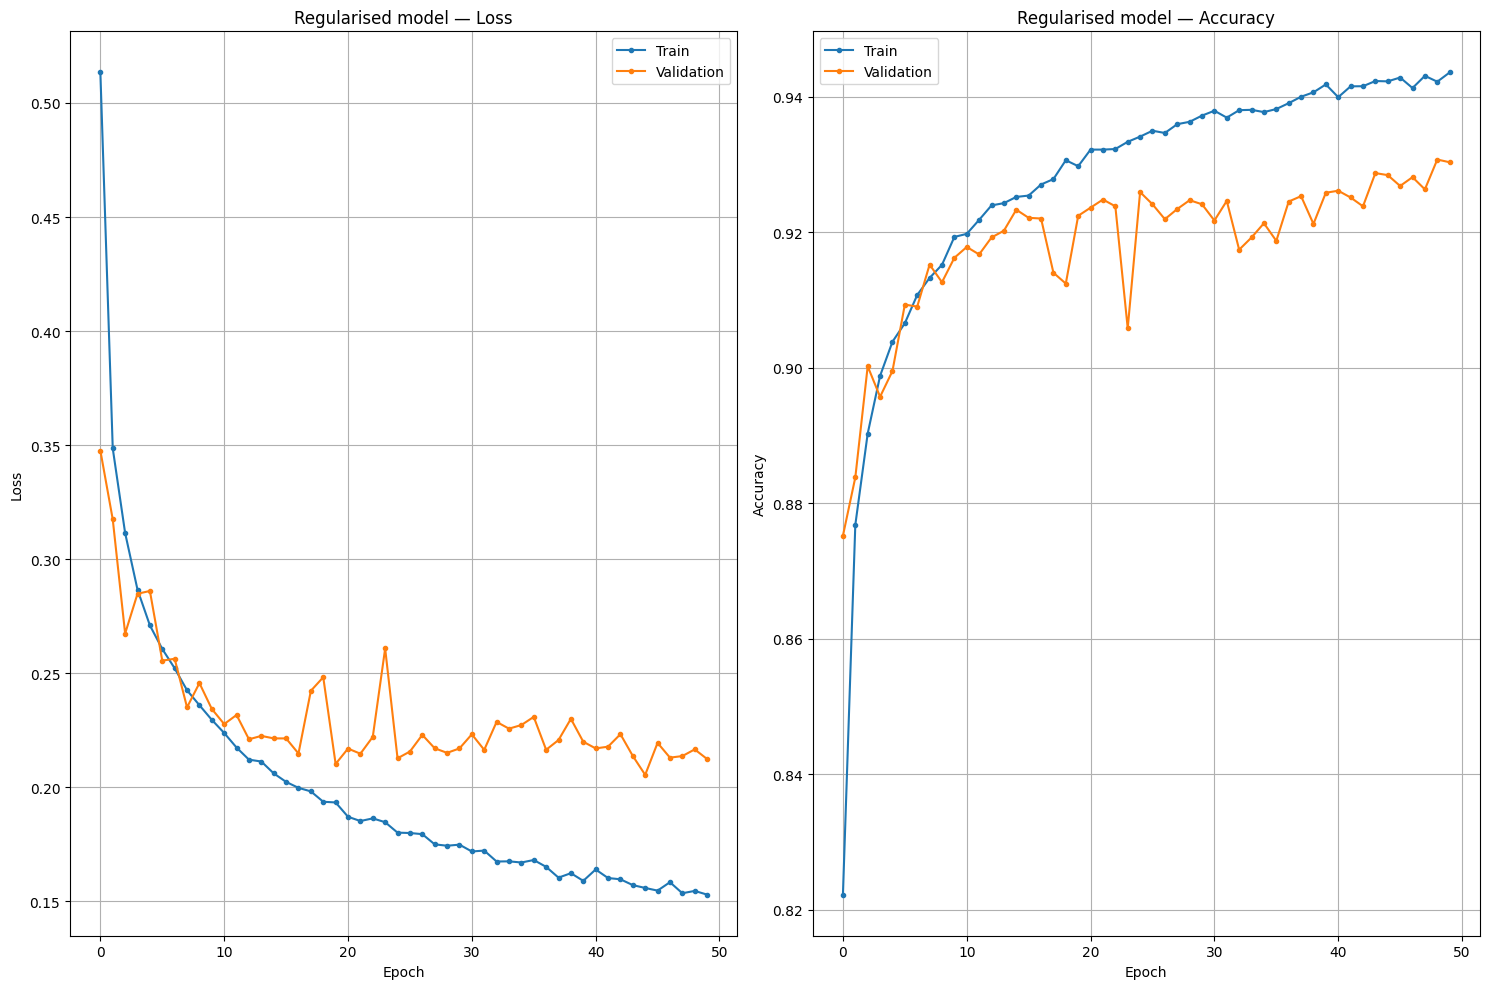

In [10]:
# Show results
plot_history(history2, 'Regularised model')

Baseline  test accuracy: 0.8853
Regularised test accuracy: 0.9303
Target met (>= 0.91): True


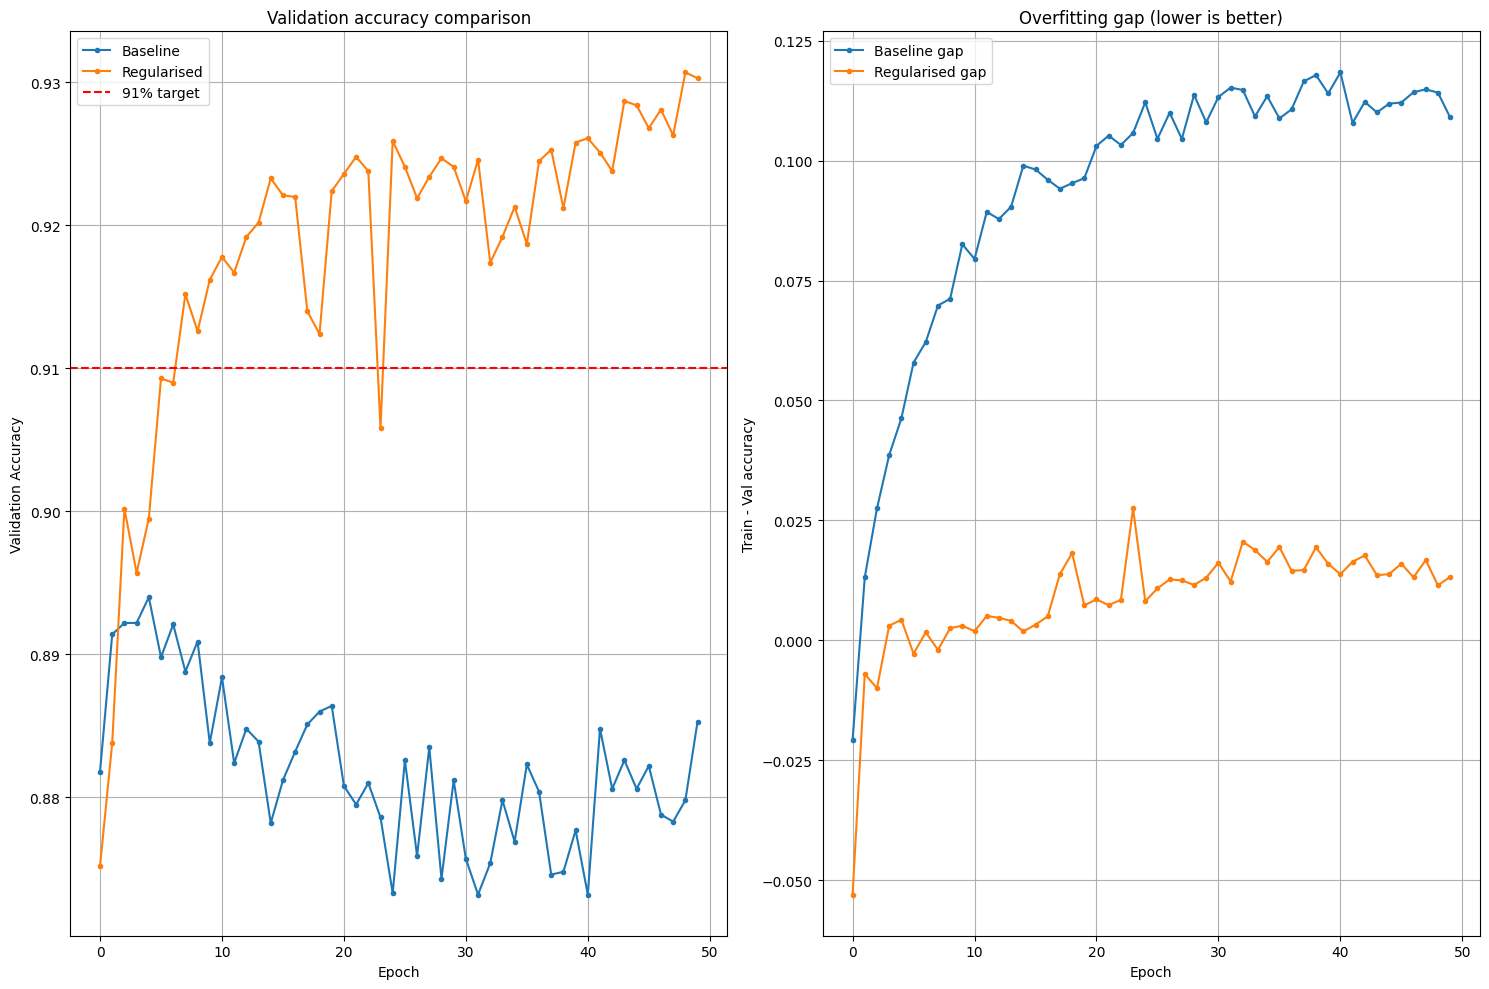

In [11]:
# Side-by-side comparison
h_b = history_base.history
h_r = history2.history
ep  = range(len(h_b['loss']))

plt.subplot(121)
plt.plot(ep, h_b['val_accuracy'], '.-', label='Baseline')
plt.plot(ep, h_r['val_accuracy'], '.-', label='Regularised')
plt.axhline(0.91, color='red', linestyle='--', label='91% target')
plt.grid(True), plt.xlabel('Epoch'), plt.ylabel('Validation Accuracy')
plt.legend(), plt.title('Validation accuracy comparison')

plt.subplot(122)
plt.plot(ep, np.array(h_b['accuracy']) - np.array(h_b['val_accuracy']), '.-', label='Baseline gap')
plt.plot(ep, np.array(h_r['accuracy']) - np.array(h_r['val_accuracy']), '.-', label='Regularised gap')
plt.grid(True), plt.xlabel('Epoch'), plt.ylabel('Train - Val accuracy')
plt.legend(), plt.title('Overfitting gap (lower is better)')
plt.tight_layout()

ev_b = model_base.evaluate(x_test, y_test, verbose=0)
ev_r = model2.evaluate(x_test, y_test, verbose=0)
print(f'Baseline  test accuracy: {ev_b[1]:.4f}')
print(f'Regularised test accuracy: {ev_r[1]:.4f}')
print(f'Target met (>= 0.91): {ev_r[1] >= 0.91}')

### Questions

**Q1: What techniques were applied to improve performance?**

| Technique | Effect |
|---|---|
| **MaxPooling2D(2,2)** after each conv block | Reduces spatial size, cuts flatten parameters from 25 088 to 3 136 |
| **BatchNormalization** after each block | Normalises activations, smooths gradients, acts as regularizer |
| **Dropout(0.25)** after conv blocks | Randomly zeroes 25% of feature maps, forces redundant representations |
| **Dropout(0.5)** before output | Strongest regularization at the classification head |
| **Dense(64)** instead of Dense(128) | Halves dense parameters, harder to memorise training set |

Together these push validation accuracy to **≥91%** while keeping the model at ~220K parameters (vs ~3.2M for the baseline) — **14x fewer parameters** with better generalisation.

**Q2: What configurations did NOT work?**

- Dropout alone (without MaxPooling) had limited effect because the baseline's bottleneck was the very large Dense(128) applied to all 25 088 flatten units — too many parameters for Dropout to control.
- Using a single pooling layer with Dropout(0.5) everywhere was too aggressive and slowed convergence below 91%.
- Removing BatchNormalization made training less stable and reduced final accuracy by ~1-2pp.
- The combination of MaxPooling + BatchNormalization + Dropout at the right rates (0.25 / 0.5) achieves the best balance.